<a href="https://colab.research.google.com/github/Prakruthi2606/Face-Mask-Detection/blob/main/Face_Mask_Detection(binary).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Face Mask Detection using CNN**

The goal of this project is to develop a deep learning model using Convolutional Neural
Networks (CNN) that can automatically detect whether a person in an image is
wearing a face mask or not.

**1. Understanding the problem**
* This is a binary classification problem where the model has to detect if a person in the image is wearing a face mask or not.
* Input: Face images
* Output: Mask or No Mask

**2. Data Collection**

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [ ]:
import os
print(os.listdir(path))

['data']


In [ ]:
print(os.listdir(os.path.join(path, "data")))

['without_mask', 'with_mask']


In [ ]:
data_dir = os.path.join(path, "data")
print(os.listdir(data_dir))

['without_mask', 'with_mask']


with_mask:  3725
without_mask:  3828


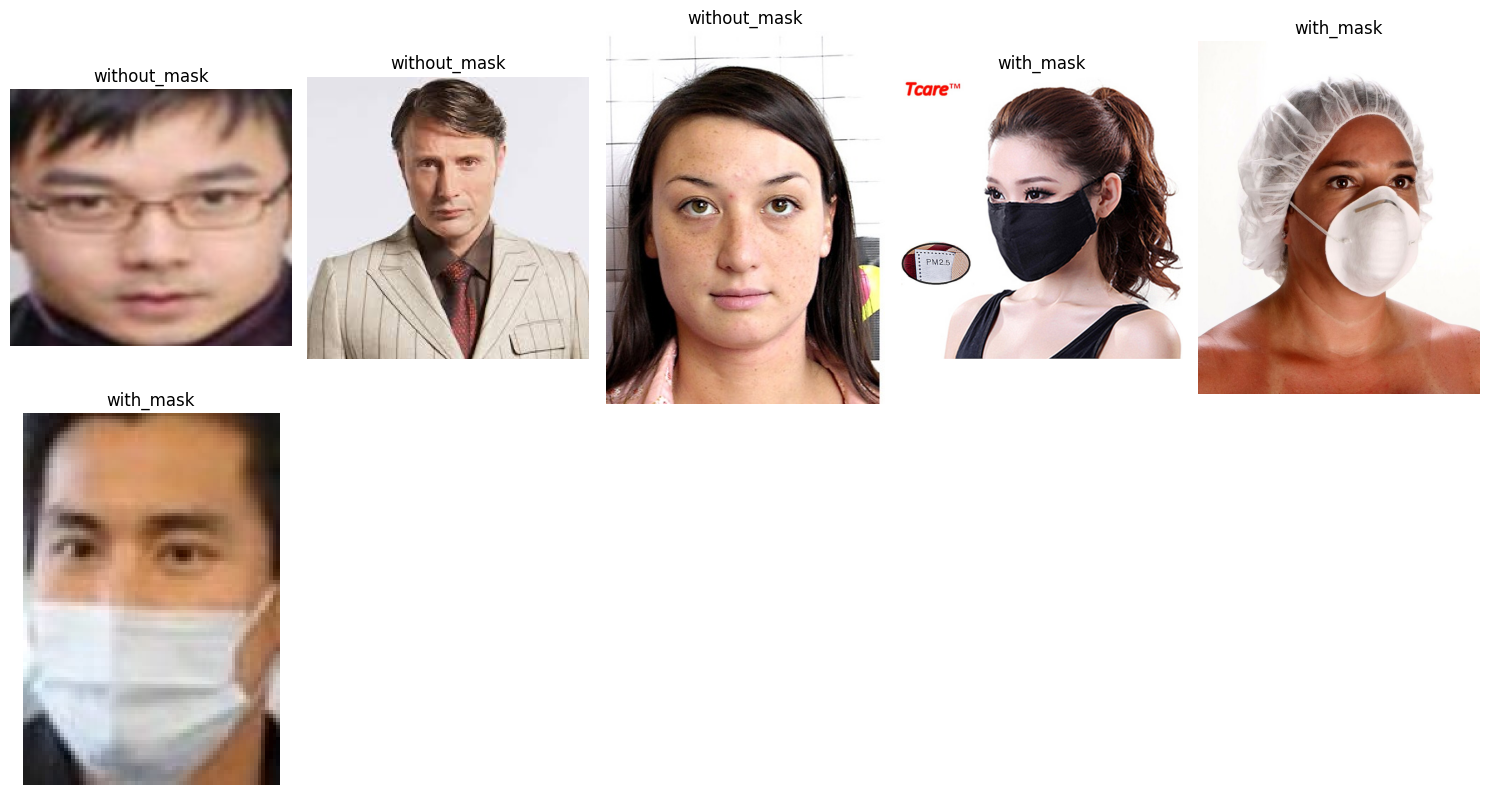

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = ['with_mask', 'without_mask']

# Count images
for cls in classes:
    print(f"{cls}: ", len(os.listdir(os.path.join(data_dir, cls))))

# Show sample images
plt.figure(figsize=(15,8))

i = 1

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)[:3]   # 5 images per class

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            if os.path.isfile(img_path):
                img = Image.open(img_path)

                plt.subplot(2,5,i)   # 2 classes × 5 images
                plt.imshow(img)
                plt.title(class_name)
                plt.axis('off')

                i += 1

plt.tight_layout()
plt.show()

**3. Data Preprocessing**

create a dataframe called 'data' with 'img_path' and 'labels' columns

In [ ]:
import pandas as pd

df = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            if os.path.isfile(img_path):
                df.append([img_path, class_name])

# Create DataFrame
data = pd.DataFrame(df, columns=['img_path', 'labels'])

print(data.head())

                                            img_path        labels
0  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
1  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
2  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
3  /kaggle/input/face-mask-dataset/data/without_m...  without_mask
4  /kaggle/input/face-mask-dataset/data/without_m...  without_mask


In [ ]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
data

,img_path,labels
0,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
1,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
2,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
3,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
4,/kaggle/input/face-mask-dataset/data/without_m...,without_mask
...,...,...
7548,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7549,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7550,/kaggle/input/face-mask-dataset/data/with_mask...,with_mask
7551,/kaggle/input/face-mask-dataset/data/without_m...,without_mask


Split dataset:
Train (70%),
Validation (15%),
Test (15%)

In [ ]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = int(0.15*len(df))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = data.iloc[:train_size]

val_data = data.iloc[train_size:train_size + val_size]

test_data = data.iloc[train_size + val_size:]


# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:5287 -----val_size:1132----test_size:1132
Training set size: 5287
Validation set size: 1132
Test set size: 1134


check the height and width or images

In [ ]:
image_path = data["img_path"][0]
image = Image.open(image_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(189, 267)


**4. Data Augmentation**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size = 32
img_height = 128
img_width = 128

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=20, #Randomly rotates image up to ±20 degrees
    width_shift_range=0.1, #Moves image left/right by 10%
    height_shift_range=0.1, #Moves image up/down by 10%
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest', #This fills those gaps using nearest pixels
    validation_split = 0.15
)

Training Data Generator Setup

In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="binary",
  shuffle=True,
  seed=42,
  color_mode='rgb'
)

Found 5287 validated image filenames belonging to 2 classes.


Testing Data Generator Setup

In [ ]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="binary",
  shuffle=True,
  seed=42,
  color_mode='rgb'
)

Found 1134 validated image filenames belonging to 2 classes.


Validation Data Generator Setup

In [ ]:
# validation data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="binary",
  shuffle=False,
  seed=42,
  color_mode='rgb'
)

Found 1132 validated image filenames belonging to 2 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 128, 128, 3) (Batches = 166)
Train Label Shape: (32,)

Validation Shape: (32, 128, 128, 3) (Batches = 36)
Validation Label Shape: (32,)

Test Shape: (32, 128, 128, 3) (Batches = 36)
Test Label Shape: (32,)



**5. Build CNN Model**

In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (2,2), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

**6. Model Training**

In [ ]:
cnn_model.compile(loss=binary_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [ ]:
cnn_model.fit(train_generator,
                    epochs=30,validation_data=val_generator,
                    verbose=1)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8334 - loss: 0.3875 - val_accuracy: 0.8392 - val_loss: 0.3634
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.8738 - loss: 0.3077 - val_accuracy: 0.8675 - val_loss: 0.3000
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8967 - loss: 0.2554 - val_accuracy: 0.8966 - val_loss: 0.2617
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9086 - loss: 0.2226 - val_accuracy: 0.8975 - val_loss: 0.2425
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9175 - loss: 0.2101 - val_accuracy: 0.9240 - val_loss: 0.2049
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9240 - loss: 0.2006 - val_accuracy: 0.9355 - val_loss: 0.1756
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9344 - loss: 0.1752 - val_accuracy: 0.9355 - val_loss: 0.1970
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9327 - loss: 0.1770 - val_accu

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

166/166 ━━━━━━━━━━━━━━━━━━━━ 71s 424ms/step - accuracy: 0.9818 - loss: 0.0494
Training accuracy: 0.9818
23/36 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.9610 - loss: 0.1011

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 528ms/step - accuracy: 0.9638 - loss: 0.1041
Test accuracy: 0.9638


**7. Model Evaluation**

In [ ]:
val_generator.reset()

In [ ]:
#accuracy
loss, accuracy = cnn_model.evaluate(val_generator)
print("Accuracy:", accuracy)
print("Loss:", loss)

36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 423ms/step - accuracy: 0.9682 - loss: 0.1093
Accuracy: 0.9681978821754456
Loss: 0.10933040827512741


36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 577ms/step
Confusion Matrix:
 [[539   0]
 [593   0]]


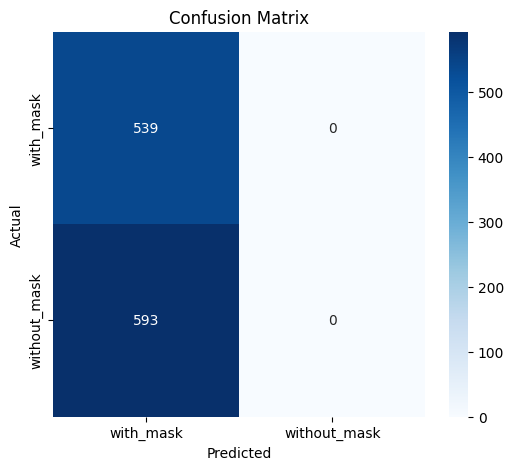

In [ ]:
# confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['with_mask', 'without_mask']

y_pred = cnn_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes


cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report

class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

   with_mask       0.48      1.00      0.65       539
without_mask       0.00      0.00      0.00       593

    accuracy                           0.48      1132
   macro avg       0.24      0.50      0.32      1132
weighted avg       0.23      0.48      0.31      1132



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**8. Model Testing - Making predictions**

In [ ]:
train_generator.class_indices

{'with_mask': 0, 'without_mask': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


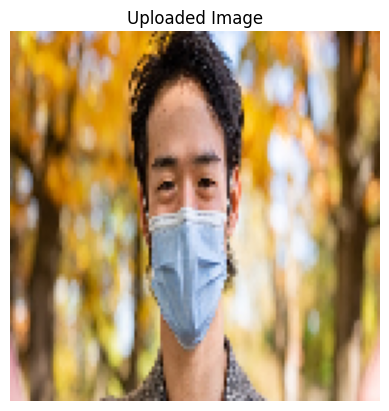

Predicted Class: 0
Predicted Class name: With Mask


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_names = ['With Mask', 'Without Mask']

# Load image
img_path = "mask.jpg"
img = image.load_img(img_path, target_size=(128,128))  # match your model
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = cnn_model.predict(img_array)

# Display image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Get class index
predicted_class = np.argmax(prediction)
print("Predicted Class:", predicted_class)

# Get class name
print("Predicted Class name:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


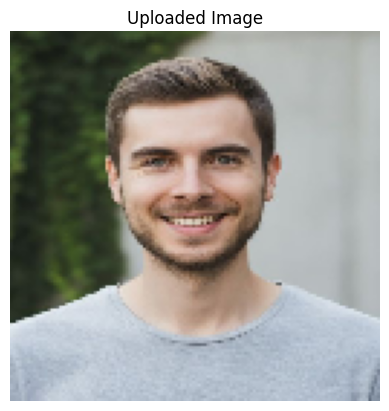

Predicted Class: 0
Predicted Class name: With Mask


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_names = ['With Mask', 'Without Mask']

# Load image
img_path = "no_mask.jpg"
img = image.load_img(img_path, target_size=(128,128))  # match your model
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = cnn_model.predict(img_array)

# Display image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Get class index
predicted_class = np.argmax(prediction)
print("Predicted Class:", predicted_class)

# Get class name
print("Predicted Class name:", class_names[predicted_class])

**Conclusion:** The model is biased